# Example-08: Mixed Hankel matrix

In [1]:
# Import

import numpy
import torch

import sys
sys.path.append('..')

from harmonica.util import data_load
from harmonica.window import Window
from harmonica.data import Data
from harmonica.frequency import Frequency
from harmonica.filter import Filter

import matplotlib.pyplot as plt

torch.set_printoptions(precision=12, sci_mode=True)
print(torch.cuda.is_available())

True


In [2]:
# Set data type and device

dtype = torch.float64
device = torch.device('cpu')

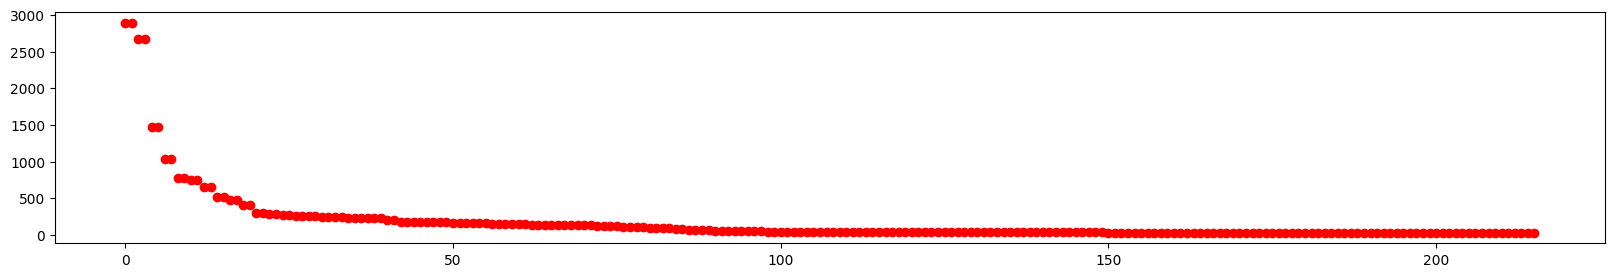

In [3]:
# Set parameters

length = 256

# Set noise std for each BPM

s = 1.0E-4*(4.0*torch.rand(54, dtype=dtype, device=device) + 1.0)

# Test TbT data with random noise

w = Window(length, 'cosine_window', 1.0, dtype=dtype, device=device)
d = Data.from_file(54, w, '../virtual_tbt.npy')
d.add_noise(s)
d.window_remove_mean()
d.normalize()

# Mixed Hankel matrix

signal = d.make_signal(length, d.work)
matrix = d.make_matrix(8192, 1, signal)

# Compute singular values

out = Filter.svd_list_randomized(rank=4*54, matrix=torch.stack([matrix]), buffer=8, count=8, cpu=True).flatten()
plt.figure(figsize=(20, 3))
plt.scatter(range(4*54), out.cpu(), c='red')
plt.show()

In [4]:
# Optimal rank is expected to be close to 2*54

print(54*2)
print(Filter.svd_optimal(torch.stack([matrix])))

108
(tensor([116]), tensor([1.922685003252e-01], dtype=torch.float64))
